<a href="https://colab.research.google.com/github/simsekergun/ENEE684/blob/main/chapter07/WG_ModeSolver_Tidy3D_Tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis of dielectric waveguides with Tidy3D

In [1]:
!pip install tidy3d

In [2]:
# standard python imports
import numpy as np
import matplotlib.pylab as plt

# tidy3D import
import tidy3d as td
from tidy3d.constants import C_0
import tidy3d.web as web
from tidy3d.plugins.mode import ModeSolver

## Example-1

Si3N4 waveguide surrounded by SiO2

In [3]:
# size of simulation domain
Lx, Ly, Lz = 5, 3, 3
dl = 0.05

# waveguide information
wg_width = 1.6
wg_height = 0.7
wg_permittivity = 1.9761**2
bg_permittivity = 1.444**2

# central frequency
wvl_um = 1.55
freq0 = C_0 / wvl_um
fwidth = freq0 / 3

# run_time in ps
run_time = 1e-12

# automatic grid specification
grid_spec = td.GridSpec.auto(min_steps_per_wvl=80, wavelength=wvl_um)


Then we set up a simulation, in this case including a straight waveguide and periodic boundary conditions. Note that Tidy3D warns us that we have not added any sources in our `Simulation` object, however for purposes of mode solving it is not necessary.

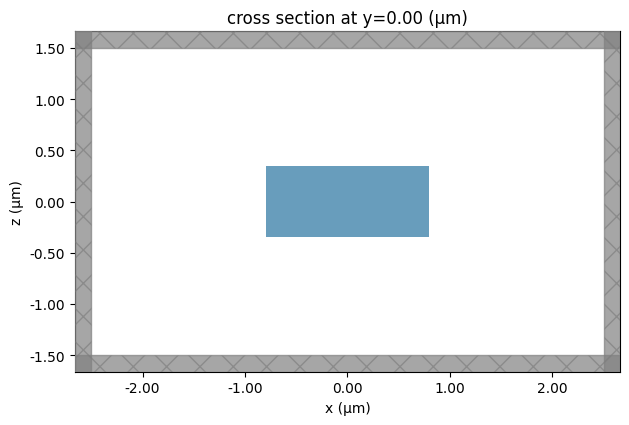

In [4]:
waveguide = td.Structure(
    geometry=td.Box(size=(wg_width, td.inf, wg_height),
                    center=[0, 0, 0]),
    medium=td.Medium(permittivity=wg_permittivity),
)

sim = td.Simulation(
    size=(Lx, Ly, Lz),
    grid_spec=grid_spec,
    medium=td.Medium(permittivity=bg_permittivity),
    structures=[waveguide],
    run_time=run_time,
    boundary_spec=td.BoundarySpec(x=td.Boundary.pml(), z=td.Boundary.pml()),
)

ax = sim.plot(y=0)
plt.show()


In [5]:
plane = td.Box(center=(0, 0, 0), size=(4, 0, 2))

mode_spec = td.ModeSpec(
    num_modes=4,
    target_neff=1.95,
)
freqs = freq0

mode_solver = ModeSolver(
    simulation=sim,
    plane=plane,
    mode_spec=mode_spec,
    freqs=freqs,
)
mode_data = mode_solver.solve()
mode_data.to_dataframe()

16:46:41 UTC WARNING: Use the remote mode solver with subpixel averaging for    
             better accuracy through 'tidy3d.web.run(...)' or the deprecated    
             'tidy3d.plugins.mode.web.run(...)'. Alternatively, you can install 
             the package 'tidy3d-extras' using 'pip install "tidy3d"' and set   
             'config.simulation.use_local_subpixel=True'.                       

wavelength     n eff  k eff  loss (dB/cm)  \
f            mode_index                                              
1.934145e+14 0                 1.55  1.795088    0.0           0.0   
             1                 1.55  1.754096    0.0           0.0   
             2                 1.55  1.648457    0.0           0.0   
             3                 1.55  1.629466    0.0           0.0   

                         TE (Ex) fraction  wg TE fraction  wg TM fraction  \
f            mode_index                                                     
1.934145e+14 0                   0.999167        0.952874        0.916335   
             1                   0.003471        0.868615        0.965917   
             2                   0.992534        0.838634        0.925403   
             3                   0.019325        0.891251        0.865613   

                         mode area  
f            mode_index             
1.934145e+14 0            1.065834  
             1            1.360498  
             2            1.498977  
             3            1.558758

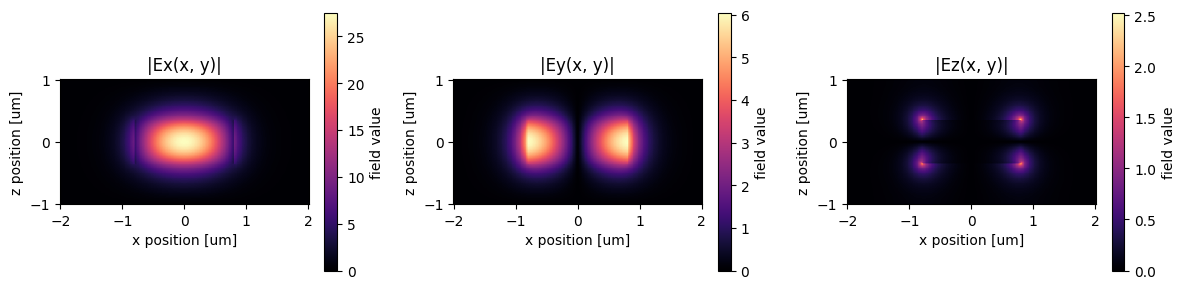

In [6]:
mode_index=0
f, (ax1, ax2, ax3) = plt.subplots(1, 3, tight_layout=True, figsize=(12, 3))
abs(mode_data.Ex.isel(mode_index=mode_index)).plot(x="x", y="z", ax=ax1, cmap="magma")
abs(mode_data.Ey.isel(mode_index=mode_index)).plot(x="x", y="z", ax=ax2, cmap="magma")
abs(mode_data.Ez.isel(mode_index=mode_index)).plot(x="x", y="z", ax=ax3, cmap="magma")

ax1.set_title("|Ex(x, y)|")
ax1.set_aspect("equal")
ax2.set_title("|Ey(x, y)|")
ax2.set_aspect("equal")
ax3.set_title("|Ez(x, y)|")
ax3.set_aspect("equal")
plt.show()


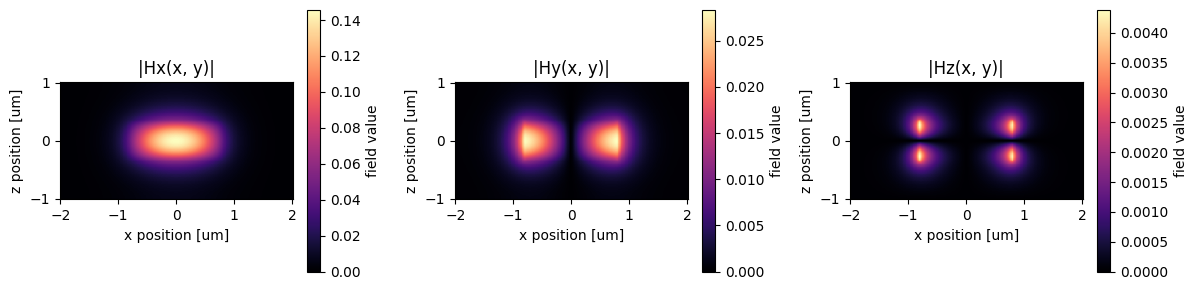

In [7]:
mode_index=1
f, (ax1, ax2, ax3) = plt.subplots(1, 3, tight_layout=True, figsize=(12, 3))
abs(mode_data.Hx.isel(mode_index=mode_index)).plot(x="x", y="z", ax=ax1, cmap="magma")
abs(mode_data.Hy.isel(mode_index=mode_index)).plot(x="x", y="z", ax=ax2, cmap="magma")
abs(mode_data.Hz.isel(mode_index=mode_index)).plot(x="x", y="z", ax=ax3, cmap="magma")

ax1.set_title("|Hx(x, y)|")
ax1.set_aspect("equal")
ax2.set_title("|Hy(x, y)|")
ax2.set_aspect("equal")
ax3.set_title("|Hz(x, y)|")
ax3.set_aspect("equal")
plt.show()

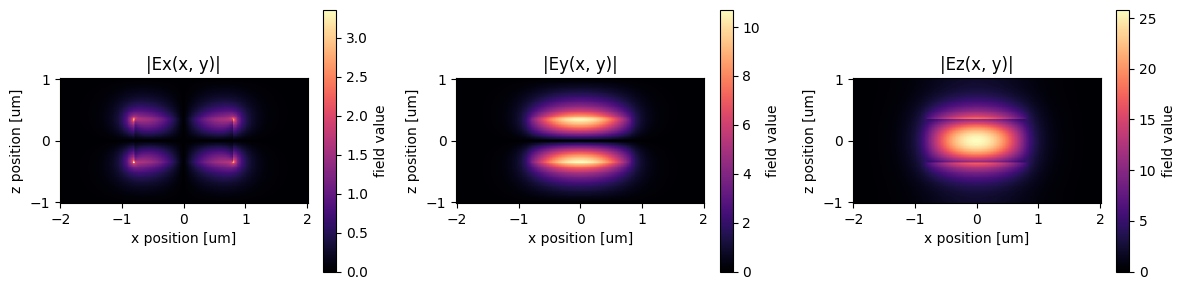

In [8]:
mode_index=1
f, (ax1, ax2, ax3) = plt.subplots(1, 3, tight_layout=True, figsize=(12, 3))
abs(mode_data.Ex.isel(mode_index=mode_index)).plot(x="x", y="z", ax=ax1, cmap="magma")
abs(mode_data.Ey.isel(mode_index=mode_index)).plot(x="x", y="z", ax=ax2, cmap="magma")
abs(mode_data.Ez.isel(mode_index=mode_index)).plot(x="x", y="z", ax=ax3, cmap="magma")

ax1.set_title("|Ex(x, y)|")
ax1.set_aspect("equal")
ax2.set_title("|Ey(x, y)|")
ax2.set_aspect("equal")
ax3.set_title("|Ez(x, y)|")
ax3.set_aspect("equal")
plt.show()


## Example-2
Waveguide on top a substrate

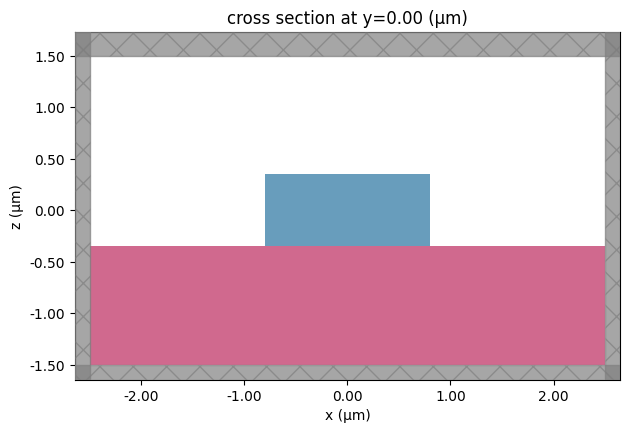

In [9]:
# size of simulation domain
Lx, Ly, Lz = 5, 3, 3
dl = 0.05

# waveguide information
wg_width = 1.6
wg_height = 0.7
wg_permittivity = 1.9761**2
substrate_permittivity = 1.6**2
bg_permittivity = 1.0**2

# central frequency
wvl_um = 1.55
freq0 = C_0 / wvl_um
fwidth = freq0 / 3

# run_time in ps
run_time = 1e-12

# automatic grid specification
grid_spec = td.GridSpec.auto(min_steps_per_wvl=80, wavelength=wvl_um)

waveguide = td.Structure(
    geometry=td.Box(size=(wg_width, td.inf, wg_height),
                    center=[0, 0, 0]),
    medium=td.Medium(permittivity=wg_permittivity),
)

substrate = td.Structure(
    geometry=td.Box(size=(Lx, td.inf, Lz/2-wg_height/2),
                    center=[0, 0, -Lz/2+(Lz/2-wg_height/2)/2]),
    medium=td.Medium(permittivity=substrate_permittivity),
)


sim = td.Simulation(
    size=(Lx, Ly, Lz),
    grid_spec=grid_spec,
    medium=td.Medium(permittivity=bg_permittivity),
    structures=[waveguide, substrate],
    run_time=run_time,
    boundary_spec=td.BoundarySpec(x=td.Boundary.pml(), z=td.Boundary.pml()),
)

ax = sim.plot(y=0)
plt.show()


In [10]:
plane = td.Box(center=(0, 0, 0), size=(3, 0, 2))

mode_spec = td.ModeSpec(
    num_modes=4,
    target_neff=1.95,
)
freqs = freq0

mode_solver = ModeSolver(
    simulation=sim,
    plane=plane,
    mode_spec=mode_spec,
    freqs=freqs,
)
mode_data = mode_solver.solve()
mode_data.to_dataframe()

wavelength     n eff  k eff  loss (dB/cm)  \
f            mode_index                                              
1.934145e+14 0                 1.55  1.785042    0.0           0.0   
             1                 1.55  1.745433    0.0           0.0   
             2                 1.55  1.608291    0.0           0.0   
             3                 1.55  1.607372    0.0           0.0   

                         TE (Ex) fraction  wg TE fraction  wg TM fraction  \
f            mode_index                                                     
1.934145e+14 0                   0.998424        0.940066        0.914692   
             1                   0.004157        0.869281        0.961895   
             2                   0.033733        0.897816        0.847267   
             3                   0.967684        0.787727        0.924936   

                         mode area  
f            mode_index             
1.934145e+14 0            0.997188  
             1            1.340879  
             2            1.555145  
             3            1.445351

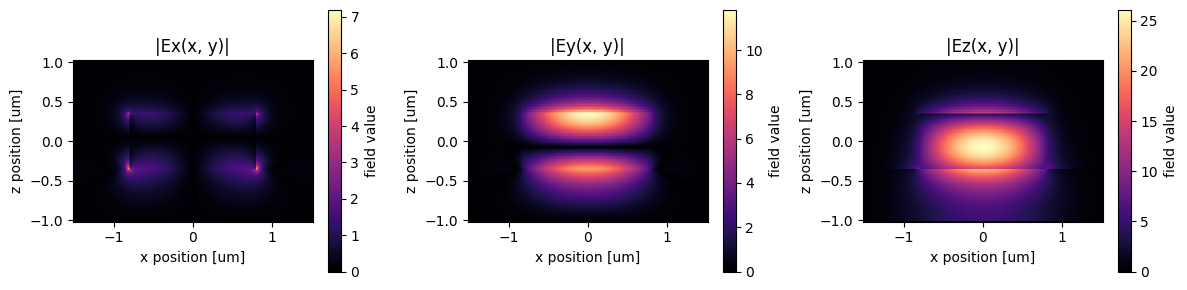

In [11]:
mode_index=1
f, (ax1, ax2, ax3) = plt.subplots(1, 3, tight_layout=True, figsize=(12, 3))
abs(mode_data.Ex.isel(mode_index=mode_index)).plot(x="x", y="z", ax=ax1, cmap="magma")
abs(mode_data.Ey.isel(mode_index=mode_index)).plot(x="x", y="z", ax=ax2, cmap="magma")
abs(mode_data.Ez.isel(mode_index=mode_index)).plot(x="x", y="z", ax=ax3, cmap="magma")

ax1.set_title("|Ex(x, y)|")
ax1.set_aspect("equal")
ax2.set_title("|Ey(x, y)|")
ax2.set_aspect("equal")
ax3.set_title("|Ez(x, y)|")
ax3.set_aspect("equal")
plt.show()


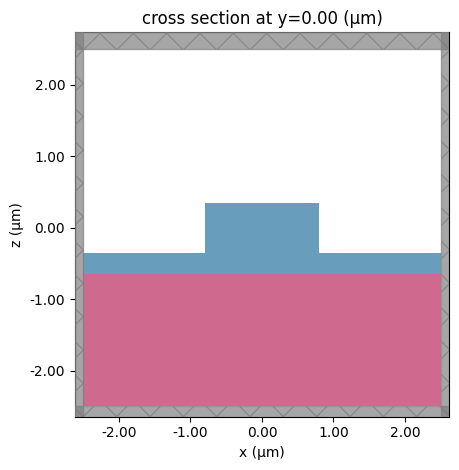

In [13]:
# size of simulation domain
Lx, Ly, Lz = 5, 3, 5
dl = 0.05

# waveguide information
wg_width = 1.6
wg_height = 0.7
film_height = 0.3
wg_permittivity = 1.9761**2
film_permittivity = wg_permittivity
substrate_permittivity = 1.6**2
bg_permittivity = 1.0**2

# central frequency
wvl_um = 1.55
freq0 = C_0 / wvl_um
fwidth = freq0 / 3

# run_time in ps
run_time = 1e-12

# automatic grid specification
grid_spec = td.GridSpec.auto(min_steps_per_wvl=80, wavelength=wvl_um)

waveguide = td.Structure(
    geometry=td.Box(size=(wg_width, td.inf, wg_height),
                    center=[0, 0, 0]),
    medium=td.Medium(permittivity=wg_permittivity),
)

film = td.Structure(
    geometry=td.Box(size=(Lx, td.inf, film_height),
                    center=[0, 0, -film_height/2-wg_height/2]),
    medium=td.Medium(permittivity=film_permittivity),
)

substrate = td.Structure(
    geometry=td.Box(size=(Lx, td.inf, Lz/2-wg_height/2-film_height),
                    center=[0, 0, -Lz/2-film_height/2+(Lz/2-wg_height/2)/2]),
    medium=td.Medium(permittivity=substrate_permittivity),
)


sim = td.Simulation(
    size=(Lx, Ly, Lz),
    grid_spec=grid_spec,
    medium=td.Medium(permittivity=bg_permittivity),
    structures=[waveguide, film, substrate],
    run_time=run_time,
    boundary_spec=td.BoundarySpec(x=td.Boundary.pml(), z=td.Boundary.pml()),
)

ax = sim.plot(y=0)
plt.show()


In [14]:
plane = td.Box(center=(0, 0, 0), size=(3, 0, 2))

mode_spec = td.ModeSpec(
    num_modes=4,
    target_neff=1.95,
)
freqs = freq0

mode_solver = ModeSolver(
    simulation=sim,
    plane=plane,
    mode_spec=mode_spec,
    freqs=freqs,
)
mode_data = mode_solver.solve()
mode_data.to_dataframe()

wavelength     n eff  k eff  loss (dB/cm)  \
f            mode_index                                              
1.934145e+14 0                 1.55  1.840103    0.0           0.0   
             1                 1.55  1.828550    0.0           0.0   
             2                 1.55  1.704723    0.0           0.0   
             3                 1.55  1.697725    0.0           0.0   

                         TE (Ex) fraction  wg TE fraction  wg TM fraction  \
f            mode_index                                                     
1.934145e+14 0                   0.997430        0.952247        0.932626   
             1                   0.003863        0.915363        0.965574   
             2                   0.017030        0.929567        0.867685   
             3                   0.980475        0.864278        0.919973   

                         mode area  
f            mode_index             
1.934145e+14 0            1.238721  
             1            1.442762  
             2            1.656824  
             3            1.885663

##Example-3
Tapered waveguide on a thin-film coated substrate

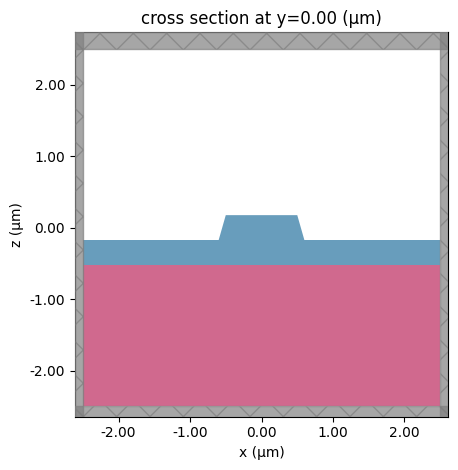

In [15]:
# size of simulation domain
Lx, Ly, Lz = 5, 3, 5
dl = 0.05

# waveguide information
wg_width_bottom = 1.2
wg_width_top = 1.0
wg_height = 0.35
film_height = 0.35

px1 = wg_width_bottom/2
py1 = -wg_height/2
px2 = wg_width_top/2
py2 = wg_height/2
px3 = -px2
py3 = py2
px4 = -px1
py4 = py1

vertices = np.array([(px1,py1), (px2,py2), (px3,py3), (px4, py4)])
tapered_wg = td.PolySlab(vertices=vertices, axis=1, slab_bounds=(-1, 1))


wg_permittivity = 2.1**2
film_permittivity = wg_permittivity
substrate_permittivity = 1.6**2
bg_permittivity = 1.0**2

# central frequency
wvl_um = 1.55
freq0 = C_0 / wvl_um
fwidth = freq0 / 3

# run_time in ps
run_time = 1e-12

# automatic grid specification
grid_spec = td.GridSpec.auto(min_steps_per_wvl=80, wavelength=wvl_um)

waveguide = td.Structure(
    geometry=tapered_wg,
    medium=td.Medium(permittivity=wg_permittivity),
)

film = td.Structure(
    geometry=td.Box(size=(Lx, td.inf, film_height),
                    center=[0, 0, -film_height/2-wg_height/2]),
    medium=td.Medium(permittivity=film_permittivity),
)

substrate = td.Structure(
    geometry=td.Box(size=(Lx, td.inf, Lz/2-wg_height/2-film_height),
                    center=[0, 0, -Lz/2-film_height/2+(Lz/2-wg_height/2)/2]),
    medium=td.Medium(permittivity=substrate_permittivity),
)


sim = td.Simulation(
    size=(Lx, Ly, Lz),
    grid_spec=grid_spec,
    medium=td.Medium(permittivity=bg_permittivity),
    structures=[waveguide, film, substrate],
    run_time=run_time,
    boundary_spec=td.BoundarySpec(x=td.Boundary.pml(), z=td.Boundary.pml()),
)

ax = sim.plot(y=0)
plt.show()


In [16]:
plane = td.Box(center=(0, 0, 0), size=(2, 0, 2.0))

mode_spec = td.ModeSpec(
    num_modes=4,
    target_neff=1.8,
)
freqs = freq0

mode_solver = ModeSolver(
    simulation=sim,
    plane=plane,
    mode_spec=mode_spec,
    freqs=freqs,
)
mode_data = mode_solver.solve()
mode_data.to_dataframe()

16:48:59 UTC WARNING: Mode field at frequency index 0, mode index 2 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

wavelength     n eff  k eff  loss (dB/cm)  \
f            mode_index                                              
1.934145e+14 0                 1.55  1.889318    0.0           0.0   
             1                 1.55  1.834459    0.0           0.0   
             2                 1.55  1.764519    0.0           0.0   
             3                 1.55  1.680161    0.0           0.0   

                         TE (Ex) fraction  wg TE fraction  wg TM fraction  \
f            mode_index                                                     
1.934145e+14 0                   0.992531        0.960059        0.899316   
             1                   0.047993        0.858624        0.947092   
             2                   0.957220        0.929057        0.873649   
             3                   0.970953        0.872866        0.865404   

                         mode area  
f            mode_index             
1.934145e+14 0            0.959796  
             1            1.068670  
             2            1.083583  
             3            0.870318